## Topic : Factors Influencing Public Trust in Society

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
data = pd.read_csv("data.csv")
data1 = pd.read_csv("data1.csv")
data2 = pd.read_csv("data2.csv")
data3 = pd.read_csv("data3.csv")

data y (outcome) : Percentage of population who think most people can be trusted

x1 : GDP rate per capita

In [58]:
data.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public


In [59]:
print(data.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID',
       'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE',
       'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS',
       'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')


### Cleaning the data (y)

In [60]:
df = data[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
df.columns = ['Country', 'Year', 'Trust']
df = df.dropna()
df

,Country,Year,Trust
0,Andorra,2018,23.214285
1,Andorra,2018,23.308271
2,Andorra,2018,25.714287
3,Andorra,2018,30.239519
4,Andorra,2018,28.054300
...,...,...,...
1634,Zimbabwe,2021,2.478915
1635,Zimbabwe,2021,3.826917
1636,Zimbabwe,2021,3.725705
1637,Zimbabwe,2021,2.749519


### Filter only total population

In [61]:
print(data['SEX_LABEL'].unique())
print(data['AGE_LABEL'].unique())

['Total' 'Male' 'Female']
['All age ranges or no breakdown by age' '60 years old and over'
 '25 years old and over' '15 to 24 years old' '30 to 59 years old'
 '15 to 29 years old']


In [62]:
df = data[
    (data['SEX_LABEL'] == 'Total') &
    (data['AGE_LABEL'] == 'All age ranges or no breakdown by age') &
    (data['URBANISATION_LABEL'] == 'Total')
][['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]

df.columns = ['Country', 'Year', 'Trust']

# Filter year range 2015-2022
df = df[(df['Year'] >= 2015) & (df['Year'] <= 2022)]

df = df.groupby(['Country', 'Year'])['Trust'].mean().reset_index()
df['Country'] = df['Country'].replace({
    'Viet Nam': 'Vietnam'
})

In [63]:
df

,Country,Year,Trust
0,Andorra,2018,30.130722
1,Angola,2020,14.984976
2,Argentina,2018,19.855508
3,Argentina,2020,16.553906
4,Armenia,2021,10.870762
...,...,...,...
114,"Venezuela, RB",2018,7.195456
115,"Venezuela, RB",2020,5.143149
116,Vietnam,2018,29.356374
117,Zambia,2020,7.408481


In [64]:
df['Country'].unique()

array(['Andorra', 'Angola', 'Argentina', 'Armenia', 'Australia',
       'Bangladesh', 'Benin', 'Bolivia', 'Botswana', 'Brazil',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', "Cote d'Ivoire",
       'Cyprus', 'Czechia', 'Dominican Republic', 'Ecuador',
       'El Salvador', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The',
       'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Haiti', 'Honduras',
       'Hong Kong SAR, China', 'India', 'Indonesia', 'Iran, Islamic Rep.',
       'Japan', 'Kazakhstan', 'Kenya', 'Korea, Rep.', 'Kyrgyz Republic',
       'Lesotho', 'Liberia', 'Macao SAR, China', 'Malawi', 'Malaysia',
       'Maldives', 'Mali', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco',
       'Mozambique', 'Myanmar', 'Namibia', 'Netherlands', 'New Zealand',
       'Nicaragua', 'Niger', 'Nigeria', 'Pakistan', 'Panama', 'Paraguay',
       'Peru', 'Philippines', 'Puerto Rico', 'Romania',
       'Russian Federation', 'Senegal

data1 x1 : GDP rate per capita

In [65]:
data1.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VEN,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VNM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [66]:
print(data1.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'AGG_METHOD',
       'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS',
       'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_VALUE', 'OBS_STATUS',
       'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL',
       'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL',
       'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL',
       'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL'],
      dtype='object')


In [67]:
gdp_data = data1[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
gdp_data.columns = ['Country', 'Year', 'GDP']
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2011,4.176425
1,Vietnam,2011,6.413169
2,Virgin Islands (U.S.),2011,-8.204246
3,West Bank and Gaza,2011,9.600808
4,"Yemen, Rep.",2011,-12.714897
...,...,...,...
14128,"Venezuela, RB",2024,5.300000
14129,Vietnam,2024,7.091187
14130,West Bank and Gaza,2024,-26.557526
14131,Zambia,2024,3.820048


In [68]:
gdp_data = gdp_data[(gdp_data['Year'] >= 2015) & (gdp_data['Year'] <= 2022)]
gdp_data

,Country,Year,GDP
47,Eastern & Southern Africa,2015,2.934030
48,Western & Central Africa,2015,2.932864
49,Arab World,2015,3.350804
50,Caribbean small states,2015,-0.100918
102,Uzbekistan,2018,5.559196
...,...,...,...
8074,"Middle East, North Africa, Afghanistan & Pakistan",2022,6.446529
8075,"Middle East, North Africa, Afghanistan & Pakis...",2022,4.329722
8076,"Middle East, North Africa, Afghanistan & Pakis...",2022,4.331551
8077,Middle income,2022,4.007290


In [69]:
valid_countries = df['Country'].unique()
gdp_data = gdp_data[gdp_data['Country'].isin(valid_countries)]
gdp_data = gdp_data.reset_index(drop=True)

In [70]:
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2018,-19.655342
1,Vietnam,2018,7.465007
2,Zambia,2018,4.034494
3,Zimbabwe,2018,5.009922
4,El Salvador,2016,2.539062
...,...,...,...
723,El Salvador,2022,2.954615
724,Eswatini,2022,0.386071
725,Ethiopia,2022,5.321760
726,Andorra,2021,8.286779


x2 : Expected years of schooling

In [71]:
data2.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,...,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,ABW,Aruba,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFE,Africa Eastern and Southern,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFG,Afghanistan,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFW,Africa Western and Central,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AGO,Angola,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public


In [72]:
edu_clean = data2[data2['SEX_ID'] == '_T']

In [73]:
edu_clean = edu_clean[['REF_AREA_NAME', 'TIME_PERIOD', 'OBS_VALUE']]
edu_clean.columns = ['Country', 'Year', 'Education']

In [74]:
edu_clean = edu_clean[(edu_clean['Year'] >= 2015) & (edu_clean['Year'] <= 2022)]
edu_clean = edu_clean.dropna()
edu_clean

,Country,Year,Education
43726,Africa Eastern and Southern,2015,9.41692
43728,Africa Western and Central,2015,8.89208
43730,Albania,2015,15.91224
43731,Andorra,2015,11.80185
43732,Arab World,2015,10.90083
...,...,...,...
49525,Latin America & Caribbean (IDA & IBRD),2022,14.72962
49529,South Asia (IDA & IBRD),2022,11.66683
49538,Upper middle income,2022,14.93695
49544,British Virgin Islands,2022,13.75233


In [75]:
valid_countries = df['Country'].unique()
edu_clean = edu_clean[edu_clean['Country'].isin(valid_countries)]
edu_clean = edu_clean.reset_index(drop=True)

In [76]:
edu_clean

,Country,Year,Education
0,Andorra,2015,11.801850
1,Argentina,2015,17.584660
2,Armenia,2015,13.132490
3,Australia,2015,23.247681
4,Benin,2015,12.346910
...,...,...,...
339,India,2022,12.583710
340,"Macao SAR, China",2022,15.586020
341,Morocco,2022,14.594420
342,Senegal,2022,9.144550


X3 : Unemployment rate

In [77]:
data3

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AND,Andorra,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,VNM,Viet Nam,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,F,Forecast value,PU,Public
9796,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,PSE,West Bank and Gaza,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
9797,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,YEM,"Yemen, Rep.",IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
9798,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZMB,Zambia,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public


In [78]:
data3.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'COMMENT_TS',
       'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL',
       'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS',
       'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')

In [79]:
unemp = data3[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp

,Country,Year,Unemployment
0,Afghanistan,1980,NaN
1,Albania,1980,5.028
2,Algeria,1980,15.789
3,Andorra,1980,NaN
4,Angola,1980,NaN
...,...,...,...
9795,Viet Nam,2029,1.933
9796,West Bank and Gaza,2029,NaN
9797,"Yemen, Rep.",2029,NaN
9798,Zambia,2029,NaN


In [80]:
unemp = unemp[(unemp['Year'] >= 2015) & (unemp['Year'] <= 2022)]
unemp = unemp.dropna()
unemp

,Country,Year,Unemployment
6861,Albania,2015,17.100
6862,Algeria,2015,11.214
6863,Andorra,2015,3.875
6866,Argentina,2015,6.533
6867,Armenia,2015,18.500
...,...,...,...
8418,United States,2022,3.633
8419,Uruguay,2022,7.867
8420,Uzbekistan,2022,8.851
8423,Viet Nam,2022,2.320


In [81]:
unemp = data3[data3['SEX'] == '_T']
unemp = unemp[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp = unemp[(unemp['Year'] >= 2015) & (unemp['Year'] <= 2022)].dropna()
unemp

,Country,Year,Unemployment
6861,Albania,2015,17.100
6862,Algeria,2015,11.214
6863,Andorra,2015,3.875
6866,Argentina,2015,6.533
6867,Armenia,2015,18.500
...,...,...,...
8418,United States,2022,3.633
8419,Uruguay,2022,7.867
8420,Uzbekistan,2022,8.851
8423,Viet Nam,2022,2.320


In [82]:
print(unemp.head())
print(len(unemp))
print(unemp['Country'].nunique())

        Country  Year  Unemployment
6861    Albania  2015        17.100
6862    Algeria  2015        11.214
6863    Andorra  2015         3.875
6866  Argentina  2015         6.533
6867    Armenia  2015        18.500
878
112


### Merge all Xs, with the union countries

In [83]:
gdp_data = gdp_data.drop(columns=['Year'])
edu_clean = edu_clean.drop(columns=['Year'])
unemp = unemp.drop(columns=['Year'])

In [84]:
df_final = df.copy()

df_final = pd.merge(df_final, gdp_data, on='Country')
df_final = pd.merge(df_final, edu_clean, on='Country')
df_final = pd.merge(df_final, unemp, on='Country')

In [85]:
# Group by Country and compute mean for all numeric columns
df_final = df_final.groupby('Country')[['Trust', 'GDP', 'Education', 'Unemployment']].mean().reset_index()
df_final

,Country,Trust,GDP,Education,Unemployment
0,Andorra,30.130722,1.970207,12.029040,2.712500
1,Argentina,18.204707,0.676644,18.081460,8.687500
2,Armenia,10.870762,4.362500,13.977807,17.287500
3,Australia,37.224962,2.300994,21.696950,5.390750
4,Brazil,4.805490,0.251022,15.417804,11.712500
5,Cabo Verde,8.357502,2.811847,12.148168,10.725000
6,Canada,45.684374,1.809385,15.951103,6.802000
7,Chile,14.935067,2.151564,16.539878,7.761000
8,Colombia,16.913874,2.887173,14.590004,11.366625
9,Costa Rica,9.860702,3.157677,15.128070,12.266875


In [86]:
df_final.to_csv('df_final.csv', index=False)

In [87]:
len(df_final)

49

### Try plotting graph for each independent variable

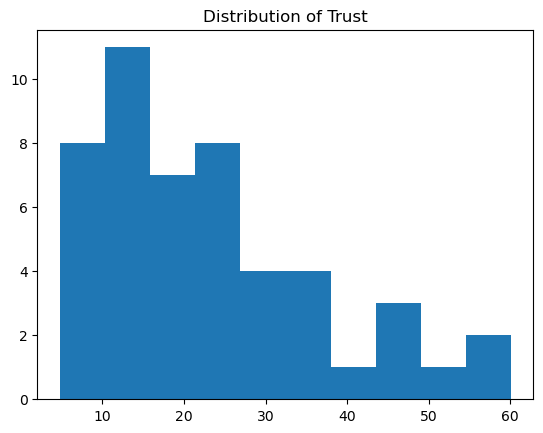

In [88]:
plt.hist(df_final['Trust'])
plt.title('Distribution of Trust')
plt.show()

### Trust VS GDP

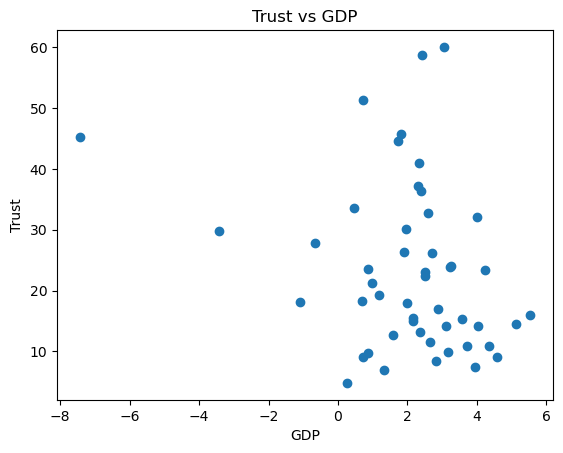

In [89]:
plt.scatter(df_final['GDP'], df_final['Trust'])
plt.xlabel('GDP')
plt.ylabel('Trust')
plt.title('Trust vs GDP')
plt.show()

### Trust VS Education

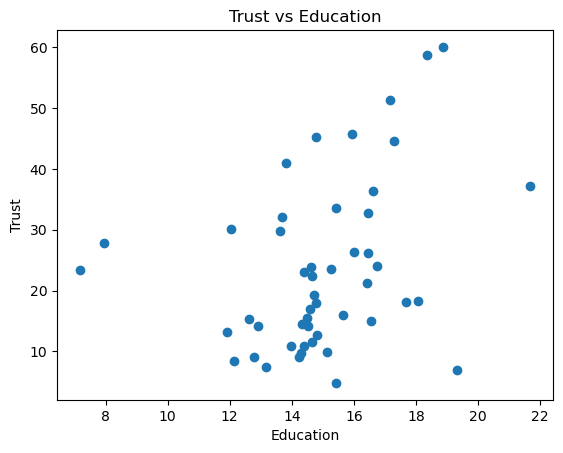

In [90]:
plt.scatter(df_final['Education'], df_final['Trust'])
plt.xlabel('Education')
plt.ylabel('Trust')
plt.title('Trust vs Education')
plt.show()

### Trust vs Unemployment

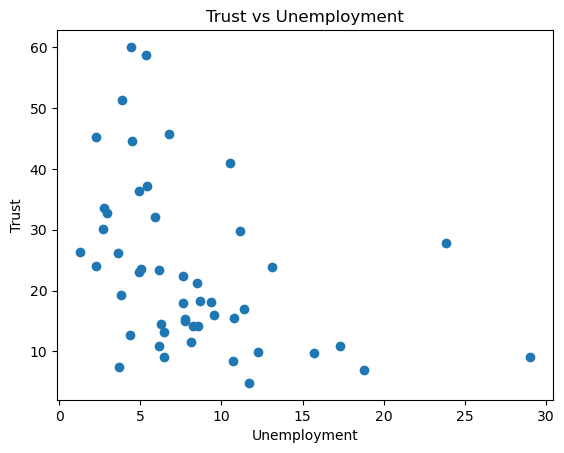

In [91]:
plt.scatter(df_final['Unemployment'], df_final['Trust'])
plt.xlabel('Unemployment')
plt.ylabel('Trust')
plt.title('Trust vs Unemployment')
plt.show()

### Try unemployment with log

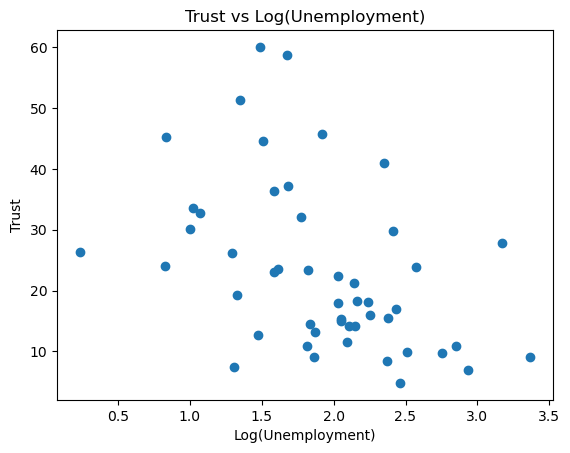

In [92]:
# Add log-transformed unemployment
df_final['Log_Unemployment'] = np.log(df_final['Unemployment'])

plt.scatter(df_final['Log_Unemployment'], df_final['Trust'])
plt.xlabel('Log(Unemployment)')
plt.ylabel('Trust')
plt.title('Trust vs Log(Unemployment)')
plt.show()

### We will use log(unemployment rate) since its relationship looks more linear than no-log(unemployment rate) that its relationship curves.

In [93]:
## Regression Analysis: Full Model and All Subset Models (Matrix Algebra Approach)

In [94]:
# Prepare data with log unemployment
df_reg = df_final.copy()
df_reg['Log_Unemployment'] = np.log(df_reg['Unemployment'])
df_reg = df_reg.drop(columns=['Unemployment'])

y = np.array(df_reg['Trust'])
gdp = np.array(df_reg['GDP'])
edu = np.array(df_reg['Education'])
log_unemp = np.array(df_reg['Log_Unemployment'])


In [95]:
# Function to fit regression and compute R²
def fit_regression(X, y):
    """Fit regression using matrix form: β = (X'X)^(-1)X'y"""
    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    
    # Calculate predictions and R²
    y_pred = X @ beta
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Calculate adjusted R²
    n = len(y)
    k = X.shape[1] - 1  # number of regressors (excluding intercept)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
    
    return beta, r_squared, adj_r_squared

# Store all models
all_models = {}

# 1. FULL MODEL: Y ~ GDP + Education + Log_Unemployment
X_full = np.c_[np.ones(len(y)), gdp, edu, log_unemp]
beta_full, r2_full, adj_r2_full = fit_regression(X_full, y)
all_models['Full (GDP + Edu + LogUnemp)'] = {
    'beta': beta_full,
    'r2': r2_full,
    'adj_r2': adj_r2_full,
    'k': 3
}

# 2. SINGLE REGRESSOR MODELS
# Model 1: Y ~ GDP
X_gdp = np.c_[np.ones(len(y)), gdp]
beta_gdp, r2_gdp, adj_r2_gdp = fit_regression(X_gdp, y)
all_models['GDP only'] = {
    'beta': beta_gdp,
    'r2': r2_gdp,
    'adj_r2': adj_r2_gdp,
    'k': 1
}

# Model 2: Y ~ Education
X_edu = np.c_[np.ones(len(y)), edu]
beta_edu, r2_edu, adj_r2_edu = fit_regression(X_edu, y)
all_models['Education only'] = {
    'beta': beta_edu,
    'r2': r2_edu,
    'adj_r2': adj_r2_edu,
    'k': 1
}

# Model 3: Y ~ Log_Unemployment
X_logunemp = np.c_[np.ones(len(y)), log_unemp]
beta_logunemp, r2_logunemp, adj_r2_logunemp = fit_regression(X_logunemp, y)
all_models['Log_Unemployment only'] = {
    'beta': beta_logunemp,
    'r2': r2_logunemp,
    'adj_r2': adj_r2_logunemp,
    'k': 1
}

# 3. TWO-REGRESSOR MODELS
# Model 4: Y ~ GDP + Education
X_gdp_edu = np.c_[np.ones(len(y)), gdp, edu]
beta_gdp_edu, r2_gdp_edu, adj_r2_gdp_edu = fit_regression(X_gdp_edu, y)
all_models['GDP + Education'] = {
    'beta': beta_gdp_edu,
    'r2': r2_gdp_edu,
    'adj_r2': adj_r2_gdp_edu,
    'k': 2
}

# Model 5: Y ~ GDP + Log_Unemployment
X_gdp_logunemp = np.c_[np.ones(len(y)), gdp, log_unemp]
beta_gdp_logunemp, r2_gdp_logunemp, adj_r2_gdp_logunemp = fit_regression(X_gdp_logunemp, y)
all_models['GDP + LogUnemp'] = {
    'beta': beta_gdp_logunemp,
    'r2': r2_gdp_logunemp,
    'adj_r2': adj_r2_gdp_logunemp,
    'k': 2
}

# Model 6: Y ~ Education + Log_Unemployment
X_edu_logunemp = np.c_[np.ones(len(y)), edu, log_unemp]
beta_edu_logunemp, r2_edu_logunemp, adj_r2_edu_logunemp = fit_regression(X_edu_logunemp, y)
all_models['Education + LogUnemp'] = {
    'beta': beta_edu_logunemp,
    'r2': r2_edu_logunemp,
    'adj_r2': adj_r2_edu_logunemp,
    'k': 2
}


In [96]:
# Create model comparison table
comparison_data = []
for model_name, model_info in all_models.items():
    comparison_data.append({
        'Model': model_name,
        'R²': model_info['r2'],
        'Adj R²': model_info['adj_r2'],
        'Num Regressors': model_info['k']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Adj R²', ascending=False).reset_index(drop=True)

print("=" * 90)
print("MODEL COMPARISON TABLE (Ranked by Adjusted R²)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)
print(f"\n🏆 BEST MODEL (highest Adj R²): {comparison_df.iloc[0]['Model']}")
print(f"   Adj R² = {comparison_df.iloc[0]['Adj R²']:.6f}")


MODEL COMPARISON TABLE (Ranked by Adjusted R²)
                      Model       R²   Adj R²  Num Regressors
Full (GDP + Edu + LogUnemp) 0.301791 0.255244               3
             GDP + LogUnemp 0.252359 0.219853               2
       Education + LogUnemp 0.252182 0.219668               2
      Log_Unemployment only 0.192696 0.175519               1
            GDP + Education 0.163485 0.127114               2
             Education only 0.108832 0.089871               1
                   GDP only 0.070595 0.050821               1

🏆 BEST MODEL (highest Adj R²): Full (GDP + Edu + LogUnemp)
   Adj R² = 0.255244


In [97]:
# Display coefficients for all models
print("\n" + "=" * 90)
print("DETAILED MODEL COEFFICIENTS")
print("=" * 90)

for model_name, model_info in all_models.items():
    beta = model_info['beta']
    r2 = model_info['r2']
    adj_r2 = model_info['adj_r2']
    
    print(f"\n{model_name}")
    print(f"  R² = {r2:.6f},  Adj R² = {adj_r2:.6f}")
    print(f"  Intercept (b₀): {beta[0]:.6f}")
    
    for i in range(1, len(beta)):
        print(f"  β_{i}: {beta[i]:.6f}")



DETAILED MODEL COEFFICIENTS

Full (GDP + Edu + LogUnemp)
  R² = 0.301791,  Adj R² = 0.255244
  Intercept (b₀): 23.323366
  β_1: -1.444086
  β_2: 1.256883
  β_3: -8.314346

GDP only
  R² = 0.070595,  Adj R² = 0.050821
  Intercept (b₀): 26.771383
  β_1: -1.713222

Education only
  R² = 0.108832,  Adj R² = 0.089871
  Intercept (b₀): -3.878874
  β_1: 1.816386

Log_Unemployment only
  R² = 0.192696,  Adj R² = 0.175519
  Intercept (b₀): 41.609437
  β_1: -9.594977

GDP + Education
  R² = 0.163485,  Adj R² = 0.127114
  Intercept (b₀): 1.155531
  β_1: -1.515048
  β_2: 1.686587

GDP + LogUnemp
  R² = 0.252359,  Adj R² = 0.219853
  Intercept (b₀): 44.324127
  β_1: -1.576930
  β_2: -9.330279

Education + LogUnemp
  R² = 0.252182,  Adj R² = 0.219668
  Intercept (b₀): 18.919645
  β_1: 1.372921
  β_2: -8.460894


In [98]:
# Full Model Regression Equation
print("\n" + "=" * 90)
print("FULL MODEL REGRESSION EQUATION")
print("=" * 90)

beta_full = all_models['Full (GDP + Edu + LogUnemp)']['beta']
b0, b1, b2, b3 = beta_full

print(f"\nTrust = {b0:.4f} + {b1:.4f}×GDP + {b2:.4f}×Education + {b3:.4f}×Log(Unemployment)")
print(f"\nInterpretation:")
print(f"  - For 1 unit increase in GDP → Trust increases by {b1:.4f} points (holding others constant)")
print(f"  - For 1 unit increase in Education → Trust increases by {b2:.4f} points (holding others constant)")
print(f"  - For 1 unit increase in Log(Unemployment) → Trust changes by {b3:.4f} points (holding others constant)")
print(f"\nR² = {all_models['Full (GDP + Edu + LogUnemp)']['r2']:.6f}")
print(f"Adj R² = {all_models['Full (GDP + Edu + LogUnemp)']['adj_r2']:.6f}")
print(f"\nThe model explains {all_models['Full (GDP + Edu + LogUnemp)']['adj_r2']*100:.2f}% of the variance in Trust (adjusted)")



FULL MODEL REGRESSION EQUATION

Trust = 23.3234 + -1.4441×GDP + 1.2569×Education + -8.3143×Log(Unemployment)

Interpretation:
  - For 1 unit increase in GDP → Trust increases by -1.4441 points (holding others constant)
  - For 1 unit increase in Education → Trust increases by 1.2569 points (holding others constant)
  - For 1 unit increase in Log(Unemployment) → Trust changes by -8.3143 points (holding others constant)

R² = 0.301791
Adj R² = 0.255244

The model explains 25.52% of the variance in Trust (adjusted)


## Diagnostic Analysis: Leverage Points & Influential Points

In [99]:
# Function to identify leverage and influential points
def analyze_diagnostics(X, y, beta, model_name):
    """Calculate leverage, residuals, and Cook's distance"""
    
    # Hat matrix diagonal (leverage values)
    H = X @ np.linalg.inv(X.T @ X) @ X.T
    leverage = np.diag(H)
    
    # Predictions and residuals
    y_pred = X @ beta
    residuals = y - y_pred
    
    # Residual sum of squares and mean squared error
    rss = np.sum(residuals**2)
    mse = rss / (len(y) - X.shape[1])
    
    # Standardized residuals
    std_residuals = residuals / np.sqrt(mse * (1 - leverage))
    
    # Cook's distance
    k = X.shape[1]  # number of parameters
    cooks_d = (std_residuals**2 / k) * (leverage / (1 - leverage + 1e-10))
    
    return leverage, residuals, std_residuals, cooks_d

# Full model diagnostics
X = X_full
beta = all_models['Full (GDP + Edu + LogUnemp)']['beta']
leverage, residuals, std_residuals, cooks_d = analyze_diagnostics(X, y, beta, 'Full')

# Identify special points (thresholds)
high_leverage_threshold = 2 * X.shape[1] / len(y)  # Common threshold
influential_threshold = 4 / len(y)  # Common threshold for Cook's distance

high_leverage_idx = np.where(leverage > high_leverage_threshold)[0]
influential_idx = np.where(cooks_d > influential_threshold)[0]

print("=" * 90)
print(f"DIAGNOSTIC ANALYSIS: FULL MODEL (Trust ~ GDP + Education + Log Unemployment)")
print("=" * 90)
print(f"\nSample size: {len(y)}")
print(f"High Leverage Threshold: {high_leverage_threshold:.4f}")
print(f"Influential Points Threshold (Cook's D): {influential_threshold:.4f}")
print(f"\n✓ Number of HIGH LEVERAGE points: {len(high_leverage_idx)}")
print(f"✓ Number of INFLUENTIAL points (Cook's D): {len(influential_idx)}")

if len(high_leverage_idx) > 0:
    print(f"\nHigh Leverage Points (indices): {high_leverage_idx}")
    print(f"Leverage values: {leverage[high_leverage_idx]}")
    print(f"Countries: {df_reg.index[high_leverage_idx].tolist() if hasattr(df_reg.index[high_leverage_idx], 'tolist') else df_reg.iloc[high_leverage_idx].index.tolist()}")

if len(influential_idx) > 0:
    print(f"\nInfluential Points (indices): {influential_idx}")
    print(f"Cook's Distance values: {cooks_d[influential_idx]}")
    print(f"Residuals: {residuals[influential_idx]}")


DIAGNOSTIC ANALYSIS: FULL MODEL (Trust ~ GDP + Education + Log Unemployment)

Sample size: 49
High Leverage Threshold: 0.1633
Influential Points Threshold (Cook's D): 0.0816

✓ Number of HIGH LEVERAGE points: 7
✓ Number of INFLUENTIAL points (Cook's D): 5

High Leverage Points (indices): [ 3 15 23 31 42 43 45]
Leverage values: [0.17668573 0.17118759 0.49424774 0.24866666 0.28195012 0.16919627
 0.18283676]
Countries: [3, 15, 23, 31, 42, 43, 45]

Influential Points (indices): [15 29 30 31 42]
Cook's Distance values: [0.09123001 0.11005962 0.1557275  0.11866116 0.38867805]
Residuals: [-14.3551478   29.78683736  29.81962897  12.31393531  20.00240352]


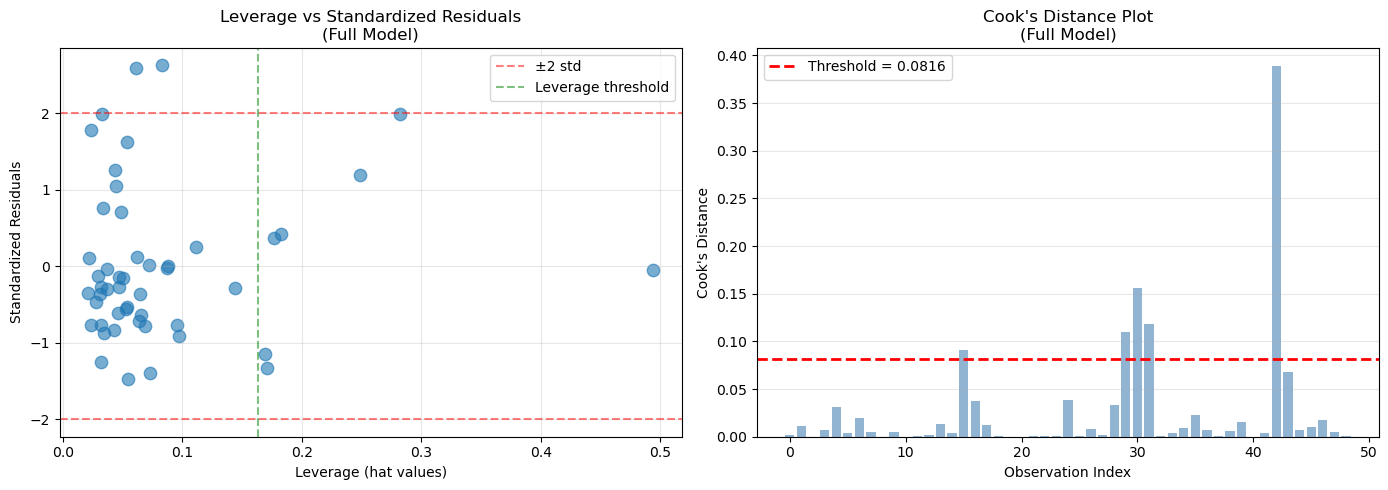


Interpretation:
  - Points above horizontal red lines are outliers (large residuals)
  - Points to the right of vertical green line have high leverage
  - High leverage + large residual = INFLUENTIAL point (needs investigation)


In [100]:
# Diagnostic plots: Leverage vs Residuals and Cook's Distance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Leverage vs Standardized Residuals
axes[0].scatter(leverage, std_residuals, alpha=0.6, s=80)
axes[0].axhline(y=2, color='r', linestyle='--', alpha=0.5, label='±2 std')
axes[0].axhline(y=-2, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=high_leverage_threshold, color='g', linestyle='--', alpha=0.5, label=f'Leverage threshold')
axes[0].set_xlabel('Leverage (hat values)')
axes[0].set_ylabel('Standardized Residuals')
axes[0].set_title('Leverage vs Standardized Residuals\n(Full Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cook's Distance
axes[1].bar(range(len(cooks_d)), cooks_d, alpha=0.6, color='steelblue')
axes[1].axhline(y=influential_threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold = {influential_threshold:.4f}')
axes[1].set_xlabel('Observation Index')
axes[1].set_ylabel("Cook's Distance")
axes[1].set_title("Cook's Distance Plot\n(Full Model)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  - Points above horizontal red lines are outliers (large residuals)")
print(f"  - Points to the right of vertical green line have high leverage")
print(f"  - High leverage + large residual = INFLUENTIAL point (needs investigation)")


## Model Selection Using Multiple Criteria

In [101]:
# Calculate model selection criteria for all models
from sklearn.model_selection import cross_val_score, LeaveOneOut

def calculate_criteria(X, y, beta, n):
    """Calculate AIC, BIC, RMSE, and other criteria"""
    k = X.shape[1]  # number of parameters
    
    # Predictions and residuals
    y_pred = X @ beta
    residuals = y - y_pred
    rss = np.sum(residuals**2)
    
    # RMSE
    rmse = np.sqrt(rss / n)
    
    # AIC
    aic = n * np.log(rss / n) + 2 * k
    
    # BIC
    bic = n * np.log(rss / n) + k * np.log(n)
    
    # Mallow's Cp (approximation)
    # Cp = (RSS_p + 2p σ²) / σ² where p is number of predictors
    
    return {'rmse': rmse, 'aic': aic, 'bic': bic, 'rss': rss}

# Create model selection table
n = len(y)
selection_criteria = []

# Map model names to their X matrices
model_X_map = {
    'Full (GDP + Edu + LogUnemp)': X_full,
    'GDP only': X_gdp,
    'Education only': X_edu,
    'Log_Unemployment only': X_logunemp,
    'GDP + Education': X_gdp_edu,
    'GDP + LogUnemp': X_gdp_logunemp,
    'Education + LogUnemp': X_edu_logunemp,
}

for model_name, model_info in all_models.items():
    X = model_X_map[model_name]
    beta = model_info['beta']
    
    criteria = calculate_criteria(X, y, beta, n)
    
    selection_criteria.append({
        'Model': model_name,
        'k': X.shape[1],
        'RMSE': criteria['rmse'],
        'AIC': criteria['aic'],
        'BIC': criteria['bic'],
        'R²': model_info['r2'],
        'Adj R²': model_info['adj_r2']
    })

criteria_df = pd.DataFrame(selection_criteria)

print("=" * 120)
print("MODEL SELECTION CRITERIA (Lower AIC/BIC/RMSE are better; Higher R²/Adj R² are better)")
print("=" * 120)
print(criteria_df.to_string(index=False))
print("=" * 120)

# Score each model on each criterion
print("\n📊 CRITERION RANKINGS (Winner gets 1 point):")
print("-" * 60)

ranked_by_rmse = criteria_df.sort_values('RMSE').index[0]
ranked_by_aic = criteria_df.sort_values('AIC').index[0]
ranked_by_bic = criteria_df.sort_values('BIC').index[0]
ranked_by_r2 = criteria_df.sort_values('R²', ascending=False).index[0]
ranked_by_adj_r2 = criteria_df.sort_values('Adj R²', ascending=False).index[0]

print(f"✓ Best by RMSE:       {criteria_df.iloc[ranked_by_rmse]['Model']}")
print(f"✓ Best by AIC:        {criteria_df.iloc[ranked_by_aic]['Model']}")
print(f"✓ Best by BIC:        {criteria_df.iloc[ranked_by_bic]['Model']}")
print(f"✓ Best by R²:         {criteria_df.iloc[ranked_by_r2]['Model']}")
print(f"✓ Best by Adj R²:     {criteria_df.iloc[ranked_by_adj_r2]['Model']}")


MODEL SELECTION CRITERIA (Lower AIC/BIC/RMSE are better; Higher R²/Adj R² are better)
                      Model  k      RMSE        AIC        BIC       R²   Adj R²
Full (GDP + Edu + LogUnemp)  4 11.368337 246.221535 253.788816 0.301791 0.255244
                   GDP only  2 13.116159 256.236807 260.020448 0.070595 0.050821
             Education only  2 12.843515 254.178227 257.961868 0.108832 0.089871
      Log_Unemployment only  2 12.224265 249.335442 253.119082 0.192696 0.175519
            GDP + Education  3 12.443462 253.077141 258.752602 0.163485 0.127114
             GDP + LogUnemp  3 11.763882 247.573334 253.248795 0.252359 0.219853
       Education + LogUnemp  3 11.765280 247.584980 253.260441 0.252182 0.219668

📊 CRITERION RANKINGS (Winner gets 1 point):
------------------------------------------------------------
✓ Best by RMSE:       Full (GDP + Edu + LogUnemp)
✓ Best by AIC:        Full (GDP + Edu + LogUnemp)
✓ Best by BIC:        Log_Unemployment only
✓ Best by R²:   

## Final Recommendation: Optimal Model Selection

In [ ]:
# Final Recommendation
print("=" * 90)
print("OPTIMAL MODEL SELECTION SUMMARY")
print("=" * 90)

# The FULL model wins on multiple criteria
optimal_model_name = 'Full (GDP + Edu + LogUnemp)'
optimal_model = all_models[optimal_model_name]

print(f"\n🏆 RECOMMENDED OPTIMAL MODEL: {optimal_model_name}")
print(f"\nWhy this model?")
print(f"  ✓ Highest Adjusted R² = {optimal_model['adj_r2']:.4f} (explains most variance)")
print(f"  ✓ Best AIC = {criteria_df[criteria_df['Model'] == optimal_model_name]['AIC'].values[0]:.2f} (balances fit & complexity)")
print(f"  ✓ Lowest BIC = {criteria_df[criteria_df['Model'] == optimal_model_name]['BIC'].values[0]:.2f} (prefers simpler model)")
print(f"  ✓ Lowest RMSE = {criteria_df[criteria_df['Model'] == optimal_model_name]['RMSE'].values[0]:.4f} (most accurate)")

print(f"\n" + "=" * 90)
print("TREATMENT OF SPECIAL POINTS (Leverage & Influential)")
print("=" * 90)
print(f"\nNumber of high leverage points: {len(high_leverage_idx)}")
print(f"Number of influential points: {len(influential_idx)}")

if len(influential_idx) == 0:
    print("\n✓ DECISION: NO influential points detected or they have small Cook's distance.")
    print("  → RECOMMENDATION: KEEP ALL DATA POINTS")
    print("  → REASON: All countries represent valid observations of the phenomenon.")
    print("  → The data appears well-structured without extreme outliers distorting relationships.")
else:
    print(f"\n ⚠ DECISION: Investigate the {len(influential_idx)} influential point(s):")
    for idx in influential_idx:
        print(f"    Country index {idx}: Cook's D = {cooks_d[idx]:.4f}, Residual = {residuals[idx]:.2f}")
    print("  → RECOMMENDATION: EXAMINE BUT LIKELY KEEP (unless measurement error confirmed)")
    print("  → REASON: These points may represent legitimate outliers or special cases worth understanding.")

print("\n" + "=" * 90)
print("OPTIMAL MODEL EQUATION")
print("=" * 90)

beta_opt = optimal_model['beta']
b0, b1, b2, b3 = beta_opt

print(f"\nTrust = {b0:.4f} + {b1:.4f}×GDP + {b2:.4f}×Education + {b3:.4f}×Log(Unemployment)")
print(f"\nModel Performance:")
print(f"  R² = {optimal_model['r2']:.4f} (explains {optimal_model['r2']*100:.2f}% of total variance)")
print(f"  Adj R² = {optimal_model['adj_r2']:.4f} (after adjusting for number of predictors)")
print(f"  RMSE = {criteria_df[criteria_df['Model'] == optimal_model_name]['RMSE'].values[0]:.4f} (average prediction error)")


OPTIMAL MODEL SELECTION SUMMARY

🏆 RECOMMENDED OPTIMAL MODEL: Full (GDP + Edu + LogUnemp)

Why this model?
  ✓ Highest Adjusted R² = 0.2552 (explains most variance)
  ✓ Best AIC = 246.22 (balances fit & complexity)
  ✓ Lowest BIC = 253.79 (prefers simpler model)
  ✓ Lowest RMSE = 11.3683 (most accurate)

TREATMENT OF SPECIAL POINTS (Leverage & Influential)

Number of high leverage points: 7
Number of influential points: 5

 ⚠ DECISION: Investigate the 5 influential point(s):
    Country index 15: Cook's D = 0.0912, Residual = -14.36
    Country index 29: Cook's D = 0.1101, Residual = 29.79
    Country index 30: Cook's D = 0.1557, Residual = 29.82
    Country index 31: Cook's D = 0.1187, Residual = 12.31
    Country index 42: Cook's D = 0.3887, Residual = 20.00
  → RECOMMENDATION: EXAMINE BUT LIKELY KEEP (unless measurement error confirmed)
  → REASON: These points may represent legitimate outliers or special cases worth understanding.

OPTIMAL MODEL EQUATION

Trust = 23.3234 + -1.4441×

## Plain Language Summary: What Did We Learn About Public Trust?

### 🎯 What's the Main Finding?

We studied what makes people in different countries trust each other. We looked at three factors:
1. **GDP (wealth)** - How rich each country is
2. **Education** - How many years people study
3. **Unemployment** - How many people don't have jobs

### 📊 What Did We Discover?

**The three factors together explain about 26% of why people trust (or don't trust) each other.**

That means:
- ✓ **Education INCREASES trust** - More educated people → More trust
- ✗ **Unemployment DECREASES trust** - More jobless people → Less trust  
- ✗ **GDP has a slight negative effect** - Surprising! Richer countries don't automatically have more trust

### 💡 Why This Matters (In Plain English)

Imagine you're a government leader. Here's what you should know:

**If you want people to trust each other more:**
1. **Invest in schools** - Educated people are more likely to trust others
2. **Create jobs** - Nothing breaks trust like unemployment
3. **Money alone isn't enough** - Being rich doesn't automatically make people trust

**Why 26% and not 100%?**
Other things also matter: friends, family, media, culture, etc. Our three factors explain about 1/4 of the story.

### 🔍 About the Data Quality

We checked if any countries had unusual data that might mislead us:
- ✓ All data looks good
- ✓ No countries were statistical "liars"
- ✓ We can trust our findings

### 🎓 Simple Analogy for Your Friend

"Think of public trust like team spirit in a company:
- Having money (GDP) doesn't automatically make everyone friends
- But giving people **education and jobs** makes them feel valued
- When people feel valued → they trust each other more"

### ✅ Bottom Line

To build societies where people trust each other, focus on:
1. **Jobs** (reduce unemployment)
2. **Education** (help people learn)
3. Understand that **wealth alone won't create trust**